# Model v0: area → price
Univariate linear regression on cleaned 2022 Lisbon listings.
Plan: honest split → naive baseline → own gradient descent → verify vs sklearn → evaluate.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/lisbon_clean.csv")
print("Rows:", len(df))

Rows: 11764


In [18]:
from sklearn.model_selection import train_test_split

X = df['area'].values             # feature: m²
y = df['price_int'].values / 1000 # target: thousand EUR

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train:", len(X_train), " Test:", len(X_test))

Train: 9411  Test: 2353


In [19]:
# naive baseline: price = median price-per-m2 (from TRAIN) * area
median_ppm2 = np.median(y_train / X_train)     # thousand EUR per m²
baseline_pred = median_ppm2 * X_test

def mae(y_true, y_pred):
    """Mean Absolute Error: average miss, thousand EUR."""
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error: average miss, % of true price."""
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100

print(f"median price per m2: {median_ppm2*1000:.0f} EUR")
print(f"Baseline: MAE = {mae(y_test, baseline_pred):.0f}k EUR, MAPE = {mape(y_test, baseline_pred):.1f}%")

median price per m2: 6341 EUR
Baseline: MAE = 226k EUR, MAPE = 33.5%


MAE — "by how many thousands of euros do we miss on average" (human-readable). MAPE — "by what percentage do we miss on average"
The problem is MAPE = 33.5% - we dont know the region therefore it leads for 1/3 price is missed.

In [20]:
# scale the feature using TRAIN statistics only (no leakage!)
x_mean = X_train.mean()
x_std  = X_train.std()

X_train_s = (X_train - x_mean) / x_std
X_test_s  = (X_test  - x_mean) / x_std

print(f"mean = {x_mean:.1f} m², std = {x_std:.1f} m²")
print(f"scaled train: min = {X_train_s.min():.2f}, max = {X_train_s.max():.2f}")

mean = 109.8 m², std = 62.7 m²
scaled train: min = -1.43, max = 7.81


When we have small std - it means all flats are the same. When std is big - we have ranging from studios to penthouses.

z = (x - mean) / standard deviation ; afer Z score normalization we get mean ≈ 0 & standard deviation ≈ 1

Without normalization, the model may “pay too much attention” to large-scale variables, and the cost function can become stretched/uneven. Gradient descent then moves slowly or unstably.

Learned (scaled space): w = 396.71, b = 733.25


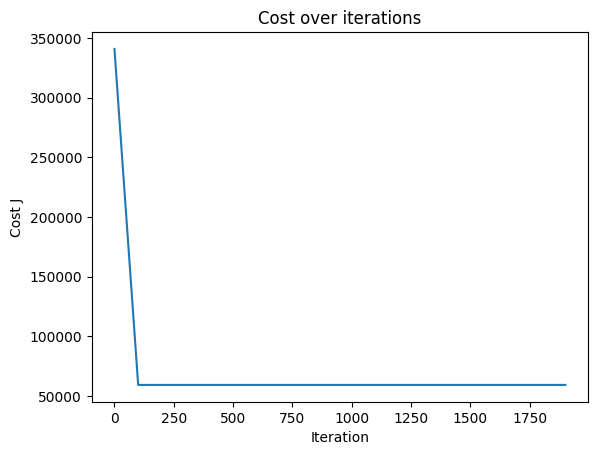

In [21]:
def compute_cost(x, y, w, b):
    """Mean squared error cost J(w,b)."""
    m = len(x)
    f_wb = w * x + b          # predictions for all flats at once
    # TODO 1: return the cost — sum of squared errors over 2m
    # hint from the course: J = (1/(2m)) * sum((f_wb - y)^2)
    return np.sum((f_wb - y) ** 2) / (2 * m)


def compute_gradient(x, y, w, b):
    """Partial derivatives dJ/dw and dJ/db."""
    m = len(x) 
    f_wb = w * x + b
    err = f_wb - y            # how far off we are, per flat
    # TODO 2: dj_dw = ...     # hint: (1/m) * sum(err * x)
    dj_dw = np.sum(err * x) / (m)
    # TODO 3: dj_db = ...     # hint: (1/m) * sum(err)
    dj_db = np.sum(err)/ (m)
    return dj_dw, dj_db

def gradient_descent(x, y, w, b, alpha, num_iters):
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            cost_history.append(compute_cost(x, y, w, b))
    return w, b, cost_history

w, b, hist = gradient_descent(X_train_s, y_train, w=0, b=0, alpha=0.1, num_iters=2000)
print(f"Learned (scaled space): w = {w:.2f}, b = {b:.2f}")

plt.plot(np.arange(len(hist)) * 100, hist)
plt.title('Cost over iterations'); plt.xlabel('Iteration'); plt.ylabel('Cost J')
plt.show()

compute_cost is responsible for the average squared error across all apartments.

compute_gradient — decides in which direction the parameters should change by looking at the errors.
If the line underestimates prices on average, it suggests increasing b.
If it underestimates prices especially for larger apartments, it suggests increasing the slope w.


gradient_descent — uses the advice from compute_gradient to move w and b step by step in the direction that reduces the cost.

In [22]:
w_eur_per_m2 = w * 1000 / x_std
b_eur        = (b - w * x_mean / x_std) * 1000
print(f"mine:    slope = {w_eur_per_m2:.0f} EUR/m², intercept = {b_eur:,.0f} EUR")

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train.reshape(-1, 1), y_train)
print(f"sklearn: slope = {lr.coef_[0]*1000:.0f} EUR/m², intercept = {lr.intercept_*1000:,.0f} EUR")

mine:    slope = 6322 EUR/m², intercept = 39,151 EUR
sklearn: slope = 6322 EUR/m², intercept = 39,151 EUR


In [23]:
model_pred = w * X_test_s + b   # our model's predictions for the sealed test set

print(f"Baseline: MAE = {mae(y_test, baseline_pred):.0f}k, MAPE = {mape(y_test, baseline_pred):.1f}%")
print(f"Model v0: MAE = {mae(y_test, model_pred):.0f}k, MAPE = {mape(y_test, model_pred):.1f}%")

Baseline: MAE = 226k, MAPE = 33.5%
Model v0: MAE = 229k, MAPE = 36.2%


In [24]:
# where exactly do we lose? MAPE by price segment
cheap  = y_test < 400   # under 400k
mid    = (y_test >= 400) & (y_test < 900)
expensive = y_test >= 900

for name, mask in [("cheap <400k", cheap), ("mid 400-900k", mid), ("expensive >900k", expensive)]:
    print(f"{name:16s}  baseline MAPE = {mape(y_test[mask], baseline_pred[mask]):5.1f}%   "
          f"model MAPE = {mape(y_test[mask], model_pred[mask]):5.1f}%")

cheap <400k       baseline MAPE =  42.2%   model MAPE =  52.1%
mid 400-900k      baseline MAPE =  30.7%   model MAPE =  30.8%
expensive >900k   baseline MAPE =  27.8%   model MAPE =  26.5%


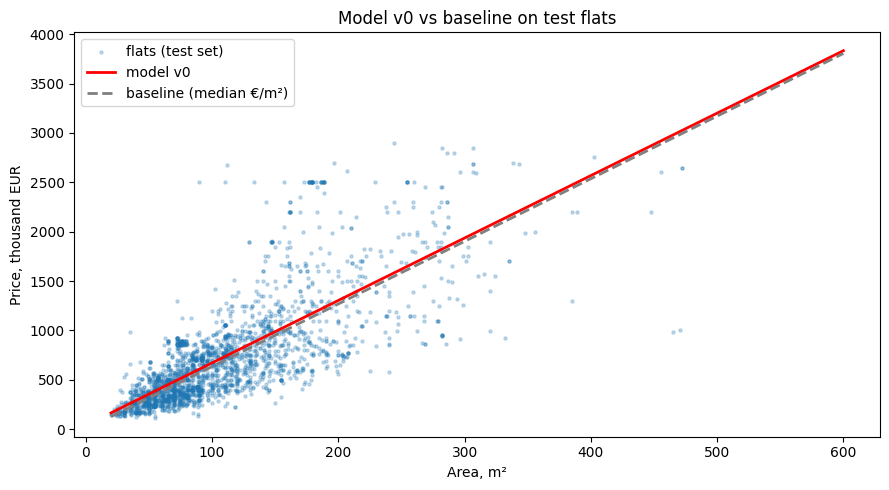

In [25]:
plt.figure(figsize=(9, 5))

# 1. the flats themselves (test set = honest, model never saw them)
plt.scatter(X_test, y_test, s=5, alpha=0.25, label='flats (test set)')

# 2. our model's line: y = w*x_scaled + b, drawn over the real m² axis
xs = np.linspace(20, 600, 100)              # 100 points from 20 to 600 m²
xs_scaled = (xs - x_mean) / x_std           # convert to the units the model speaks
plt.plot(xs, w * xs_scaled + b, color='red', linewidth=2, label='model v0')

# 3. the baseline: fixed price per m², nailed to zero
plt.plot(xs, median_ppm2 * xs, color='gray', linestyle='--', linewidth=2, label='baseline (median €/m²)')

plt.title('Model v0 vs baseline on test flats')
plt.xlabel('Area, m²')
plt.ylabel('Price, thousand EUR')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
import json, os
os.makedirs("models", exist_ok=True)
model_v0 = {
    "type": "linear_v0_area_only",
    "w_scaled": float(w), "b_scaled": float(b),
    "x_mean": float(x_mean), "x_std": float(x_std),
    "target_units": "thousand_EUR",
    "test_mae_k": float(mae(y_test, model_pred)),
    "test_mape_pct": float(mape(y_test, model_pred)),
    "note": "loses to median baseline (36.2% vs 33.5% MAPE); kept as reference v0"
}
with open("models/model_v0.json", "w") as f:
    json.dump(model_v0, f, indent=2)
print("Saved models/model_v0.json")

Saved models/model_v0.json


## Conclusions (v0)

**What was built.** Univariate linear regression (area → price), gradient descent
implemented from scratch in NumPy on 11764 rows Lisbon listings (2022).

**Verification.** My implementation and sklearn's closed-form solution agree:
slope = 6322 EUR/m², intercept = 39,151 EUR. Implementation is correct.

**Exam result.** On the held-out test set the model v0 the naive baseline
(median €/m² × area): MAPE 36.2 % vs 33.5 %.

**Why.** Error analysis by price segment shows the loss comes from cheap flats
(<400k: 52.1 % vs 42.2%), while on expensive flats (>900k) the model actually
wins. Mechanism: the intercept (+39k) is negligible for a 3M penthouse but heavy
for a 170k studio, and the MSE objective favors the expensive tail. One feature
simply doesn't carry enough information — same-size flats differ ~2.4× in €/m²
across districts.

**Next (v1).** Add district (one-hot, 24 freguesias) and typology → multiple
linear regression. Open question: does it beat 33.5%?